# Candidate Job Role Analysis

This notebook performs exploratory data analysis on the Candidate Job Role dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
data_path = "../data/raw/candidate_job_role/candidate_job_role_dataset.csv"
df = pd.read_csv(data_path)
df.head()

,candidate_id,skills,qualification,experience_level,job_role
0,1,"Python, SQL, TensorFlow, Machine Learning, Com...",Master's in Data Science,Senior,Data Scientist
1,2,"HTML, CSS, JavaScript, React, Teamwork",Bachelor's in Computer Science,Mid,Frontend Developer
2,3,"Java, Spring, SQL, REST APIs, Problem Solving",Bachelor's in Software Engineering,Senior,Backend Developer
3,4,"Figma, Adobe XD, UI/UX Design, Creativity",Bachelor's in Design,Entry,Designer
4,5,"Python, Django, JavaScript, React, Agile",Master's in Computer Science,Mid,Full Stack Python Developer


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (1000, 5)

Columns: ['candidate_id', 'skills', 'qualification', 'experience_level', 'job_role']


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   candidate_id      1000 non-null   int64
 1   skills            1000 non-null   str  
 2   qualification     1000 non-null   str  
 3   experience_level  1000 non-null   str  
 4   job_role          1000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 39.2 KB


In [5]:
print("Missing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
 candidate_id        0
skills              0
qualification       0
experience_level    0
job_role            0
dtype: int64

Duplicate Rows: 0


In [6]:
df.describe(include='all')

,candidate_id,skills,qualification,experience_level,job_role
count,1000.000000,1000,1000,1000,1000
unique,NaN,98,17,4,22
top,NaN,"PHP, Laravel, MySQL, JavaScript",Bachelor's in Computer Science,Mid,Mobile Developer
freq,NaN,25,349,401,75
mean,500.500000,NaN,NaN,NaN,NaN
std,288.819436,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,250.750000,NaN,NaN,NaN,NaN
50%,500.500000,NaN,NaN,NaN,NaN
75%,750.250000,NaN,NaN,NaN,NaN


In [7]:
print("Unique Experience Levels:", df['experience_level'].unique())
print("Unique Job Roles:", df['job_role'].nunique())

Unique Experience Levels: <StringArray>
['Senior', 'Mid', 'Entry', 'Entry,']
Length: 4, dtype: str
Unique Job Roles: 22


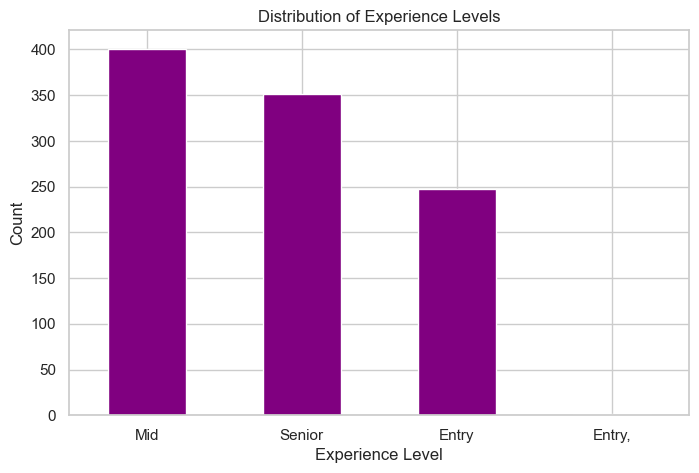

In [8]:
plt.figure(figsize=(8, 5))
df['experience_level'].value_counts().plot(kind='bar', color='purple')
plt.title("Distribution of Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

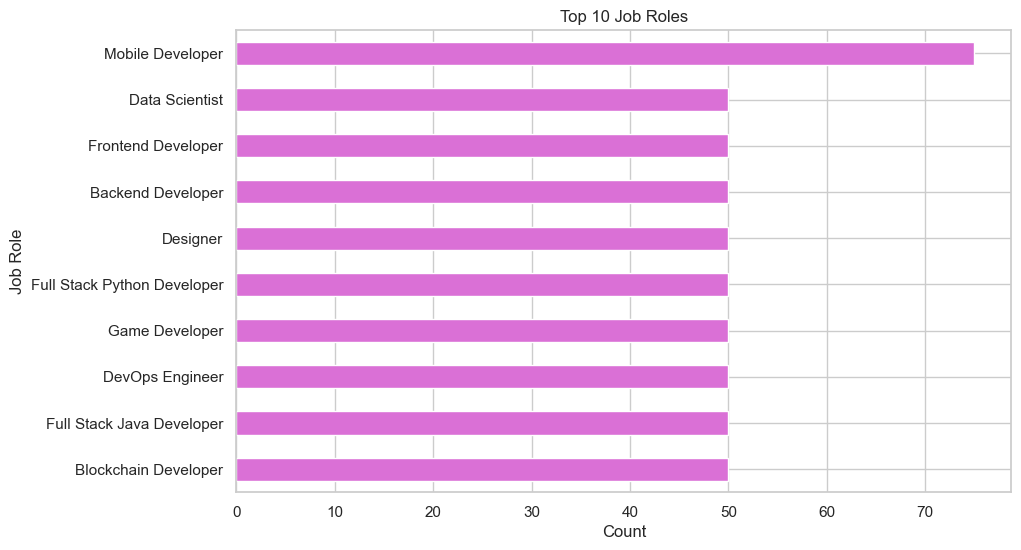

In [9]:
plt.figure(figsize=(10, 6))
df['job_role'].value_counts().head(10).plot(kind='barh', color='orchid')
plt.title("Top 10 Job Roles")
plt.xlabel("Count")
plt.ylabel("Job Role")
plt.gca().invert_yaxis()
plt.show()

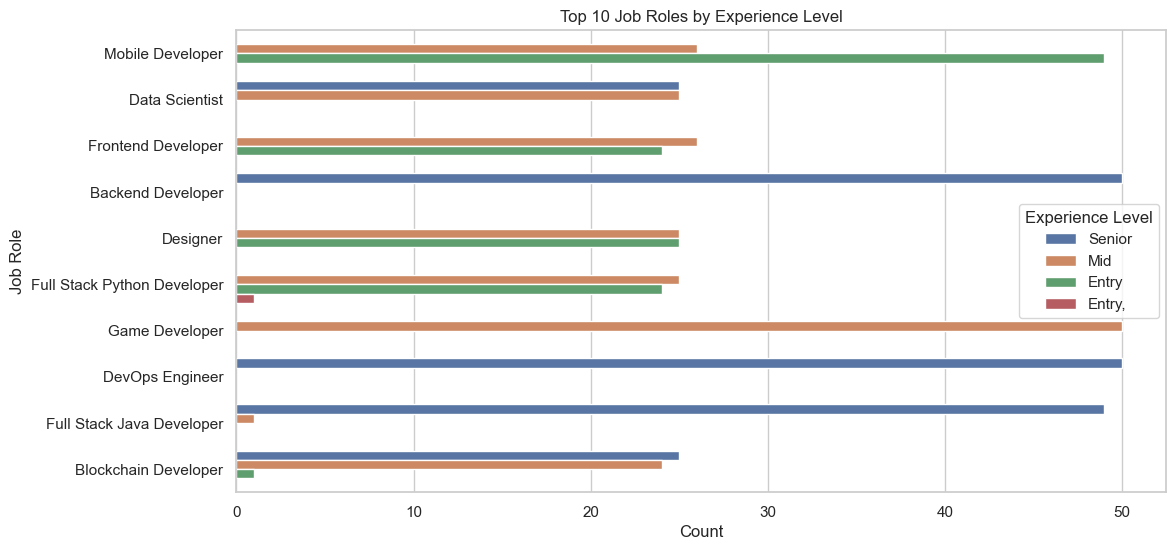

In [10]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='job_role', hue='experience_level', order=df['job_role'].value_counts().index[:10])
plt.title("Top 10 Job Roles by Experience Level")
plt.xlabel("Count")
plt.ylabel("Job Role")
plt.legend(title="Experience Level")
plt.show()

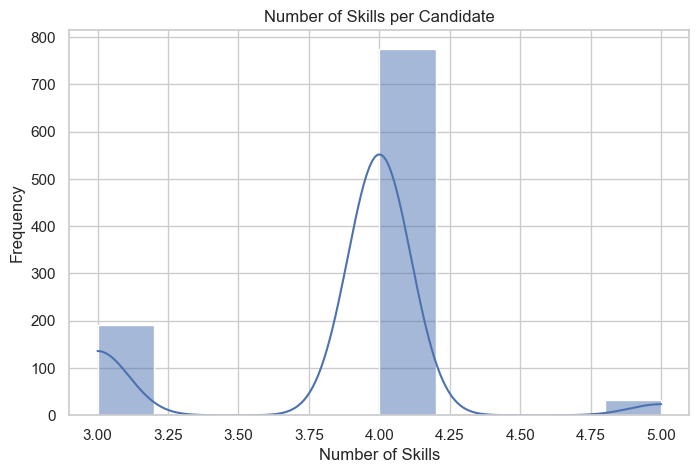

In [11]:
df['parsed_skills'] = df['skills'].fillna("").apply(lambda x: [s.strip() for s in x.split(',')])
df['num_skills'] = df['parsed_skills'].apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(df['num_skills'], bins=10, kde=True)
plt.title("Number of Skills per Candidate")
plt.xlabel("Number of Skills")
plt.ylabel("Frequency")
plt.show()

### Conclusion

- The dataset contains 1,000 candidate profiles.
- No missing values or duplicates were found.
- Experience levels are categorized (e.g., Senior, Mid, Entry).
- Job roles cover a variety of positions, with certain roles like Backend Developer and Data Scientist being prominent.
- The dataset is well-structured for modeling relationships between candidate skills, experience, and their corresponding job roles.